# Knapsack: runtime, ablation, and convergence (CLEMO)

This notebook reproduces the runtime, ablation, and convergence results for
the **continuous Knapsack Problem (KP)** from
*"Coherent Local Explanations for Mathematical Optimization"*. It complements
`02_knapsack_main.ipynb`, which reproduces the main fidelity/coherence/
stability comparison (Table 2).

Reproduces:

- **Table 3** -- runtime of LR, DTR, and CLEMO for KP instances of 5, 10, 20,
  and 40 items.
- **Table C.5** (appendix) -- ablation study on a 5-item KP instance, showing
  the effect of each coherence regularizer (`R_C1`, `R_C2`) in isolation and
  combined.
- **Table C.6** (appendix) -- comparison of SciPy `minimize` solvers for the
  CLEMO loss on a 5-item KP instance.
- **Figure 2** -- mean/std over 10 instances of infidelity, incoherence, and
  runtime as a function of the number of CLEMO (SLSQP) iterations, for a
  25-item KP.

Requires a working Gurobi installation (via `pyomo`'s `gurobi_direct`
interface) and the Pisinger knapsack instances in `data/instances/`.

Runtime: the 40-item KP and the 25-item / 10-instance convergence experiment
(Figure 2) are the most expensive parts -- expect this notebook to take
significantly longer than the other three (potentially tens of minutes,
depending on the Gurobi license and machine).


## 1. Setup

In [1]:
import copy
import time
from dataclasses import dataclass
from typing import Callable, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

import pyomo.environ as pyo
from pyomo.opt import TerminationCondition

solver = pyo.SolverFactory("gurobi_direct")


## 2. Problem sizes and the continuous Knapsack model

We consider the continuous knapsack problem

```
max c^T x
s.t. w^T x <= 1
     0 <= x <= 1
```

with `x` the (fractional) decision vector, `c` the item values, and `w` the
item weights. Both `c` and `w` (concatenated as `theta = (c, w)`) are
treated as sensitive parameters, giving `2n` features for `n` items.

For Table 3 we consider four problem sizes; for Figure 2 we additionally use
a 25-item instance (`index = -1` below).


In [2]:
np.random.seed(42)

# Problem sizes considered for the runtime experiment (Table 3)
nr_items = [5, 10, 20, 40]
smple_sz = 1000
epsilon = 1e-3

# Implied dimensions per problem size
nr_trgts = [n + 1 for n in nr_items]
nr_ftres = [2 * n for n in nr_items]
nr_ftres_intrcpt = [n + 1 for n in nr_ftres]
features = [list(range(n)) for n in nr_ftres]


In [3]:
def model_KS_cts(vals, output='goal', solver=solver):
    """Solve the continuous knapsack problem h(theta) with Gurobi via Pyomo.

    Args:
        vals: concatenation (c, w) of item values and weights, length 2n
              (the budget b = 1 is implicit).
        output: one of {'goal', 'bounded'/'feasibility', 'decision vector', 'all'}.

    Returns:
        Depending on `output`: the optimal objective value, a feasibility
        flag, the optimal decision vector, or [objective, x_1, ..., x_n].
    """
    n = len(vals) // 2  # vals = (c_1..c_n, w_1..w_n); budget b=1 is implicit

    model = pyo.ConcreteModel('Knapsack continuous model')
    model.x = pyo.Var(range(n), domain=pyo.NonNegativeReals, bounds=(0, 1))
    model.objective = pyo.Objective(
        expr=sum(vals[i] * model.x[i] for i in range(n)), sense=pyo.maximize)
    model.budget = pyo.Constraint(
        expr=sum(vals[i + n] * model.x[i] for i in range(n)) <= 1.0)

    result = solver.solve(model)

    if output == 'goal':
        return model.objective()
    elif output in ('bounded', 'feasibility'):
        return result.solver.termination_condition != TerminationCondition.infeasibleOrUnbounded
    elif output == 'decision vector':
        return [pyo.value(model.x[i]) for i in range(n)]
    elif output == 'all':
        return [model.objective()] + [pyo.value(model.x[i]) for i in range(n)]
    raise ValueError(f"Unsupported output type: {output!r}")


## 3. Sampling helpers

Sampling, weighting, and warm-start helpers, shared with the other knapsack
notebook. Samples are drawn by perturbing `theta = (c, w)` with multiplicative
Gaussian noise, keeping only feasible and bounded perturbations.


In [ ]:
def sample_perturbations_normal(orig, ftr_index_list, model, hyperparams=None,
                                 mean=0, var=0.2, size=1000,
                                 feasibility_check=True, bounded_check=True):
    """Draw `size` perturbations of `orig`, keeping feasible & bounded ones.

    Each sampled feature `j` in `ftr_index_list` is perturbed multiplicatively:
    `theta_j -> theta_j + N(mean, (var * theta_j)^2)`. The first row of the
    returned array is always `orig` itself (the present problem).
    """
    hyperparams = hyperparams or {}
    samples = [orig]
    while len(samples) < size:
        candidate = copy.deepcopy(orig)
        for j in ftr_index_list:
            candidate[j] += np.random.normal(mean, candidate[j] * var)

        ok = True
        if feasibility_check:
            ok = ok and model(candidate, output='feasibility', **hyperparams)
        if bounded_check:
            ok = ok and model(candidate, output='bounded', **hyperparams)
        if ok:
            samples.append(np.asarray(candidate))

    return np.asarray(samples)


def get_values_from_samples(samples, model, hyperparams=None):
    """Apply `model` to each sample and collect the outputs h(theta_i)."""
    hyperparams = hyperparams or {}
    return [model(s, **hyperparams) for s in samples]


def std_weight_function(a, b, ftr_index_list, kernel_width=None):
    """RBF kernel weight w_i = exp(-d(a,b)^2 / nu^2), Eq. (11)."""
    d = np.linalg.norm(a - b)
    nu = (0.75 * len(ftr_index_list)) if kernel_width is None else kernel_width
    return np.exp(-(d ** 2) / (2 * nu ** 2))


def get_weights_from_samples(samples, ftr_index_list, function=None, width=None):
    """RBF weights of all samples relative to the first sample (theta_0)."""
    origin = samples[0]
    if function is not None:
        return [function(origin, s) for s in samples]
    return [std_weight_function(origin, s, ftr_index_list, width) for s in samples]


## 4. Build the KP instances and sample datasets

For Table 3 we generate one KP instance per problem size (5, 10, 20, 40
items), each derived from the first Pisinger uncorrelated 50-item instance
(`Instances/00Uncorrelated/s000.kp`), rescaled so the items' total weight is
randomly between 1.1x and 1.3x the budget.


In [5]:
# Load the first Pisinger uncorrelated instance (50 items)
with open('../data/instances/00Uncorrelated/s000.kp') as f:
    lines = f.readlines()

ins_b = int(lines[2])
ins_v, ins_w = [], []
for line in lines[4:]:
    v, w = line.split()
    ins_v.append(int(v))
    ins_w.append(int(w))


In [6]:
# Build one instance per problem size, rescaled so total weight is 1.1-1.3x the budget
ins_dict = {}
for n in nr_items:
    w_sum = sum(ins_w[:n])
    scale = np.random.uniform(1.1, 1.3)
    c = [v / w_sum * scale for v in ins_v[:n]]
    w = [v / w_sum * scale for v in ins_w[:n]]
    ins_dict[f'{n} items'] = {'c,A,b': np.concatenate((c, w, [1.0]))}
    print(f'{n} items: total scaled weight = {sum(w):.3f}')


5 items: total scaled weight = 1.175
10 items: total scaled weight = 1.290
20 items: total scaled weight = 1.246
40 items: total scaled weight = 1.220


In [7]:
# Sample 1000 perturbations per instance and solve each with Gurobi
for i, key in enumerate(ins_dict):
    samples = sample_perturbations_normal(
        ins_dict[key]['c,A,b'], features[i], model=model_KS_cts, size=smple_sz)
    ins_dict[key]['smpl_vls'] = samples[:, features[i]]
    ins_dict[key]['Samples'] = np.concatenate(
        (ins_dict[key]['smpl_vls'], np.ones((smple_sz, 1))), axis=1)
    ins_dict[key]['Actuals'] = get_values_from_samples(samples, model_KS_cts, {'output': 'all'})

    d_list = [np.linalg.norm(samples[0] - s) for s in samples]
    ins_dict[key]['Weights'] = get_weights_from_samples(samples, features[i], width=np.mean(d_list))


## 5. CLEMO loss functions (parametrized by problem size)

Same loss decomposition as in `02_knapsack_main.ipynb` (Eq. 10), but
parametrized by an `index` into `nr_items` / `nr_trgts` / ... so the same
code handles all problem sizes.


In [ ]:
def lss_all(beta, X, Y, W, index, lgr_std=1, lgr_obj=1, lgr_cns=1, oneD=True):
    """Total CLEMO loss (Eq. 10) for the `index`-th problem size."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt[index], nr_trgts[index])

    W = np.asarray(W)
    idx = list(range(len(X)))

    pred = np.matmul(X, beta)
    std_err = np.sum(W[:, None] * np.square(Y - pred))
    obj_err = np.sum(W[idx] * np.square(
        pred[:, 0] - np.sum(pred[:, 1:] * X[:, :nr_items[index]], axis=1))[idx])
    cns_err = np.sum(W[idx] * np.maximum(
        0, np.sum(pred[:, 1:] * X[:, nr_items[index]:-1], axis=1) - 1)[idx])

    return lgr_std * std_err + lgr_obj * obj_err + lgr_cns * cns_err


def lss_std(beta, X, Y, W, index, oneD=True):
    """Fidelity loss (weighted squared error over all outputs)."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt[index], nr_trgts[index])
    W = np.asarray(W)
    return np.sum(W[:, None] * np.square(Y - np.matmul(X, beta)))


def lss_obj(beta, X, Y, W, index, oneD=True):
    """Objective-coherence loss: violation of condition (3), R_C1."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt[index], nr_trgts[index])
    W = np.asarray(W)
    pred = np.matmul(X, beta)
    return np.sum(W * np.square(pred[:, 0] - np.sum(pred[:, 1:] * X[:, :nr_items[index]], axis=1)))


def lss_cns(beta, X, Y, W, index, oneD=True):
    """Feasibility loss: violation of condition (4), R_C2."""
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt[index], nr_trgts[index])
    W = np.asarray(W)
    pred = np.matmul(X, beta)
    return np.sum(W * np.maximum(0, np.sum(pred[:, 1:] * X[:, nr_items[index]:-1], axis=1) - 1))


def lss_all_jac_sg(beta, X, Y, W, index, lgr_std=1, lgr_obj=1, lgr_cns=1, oneD=True):
    """(Sub)gradient of `lss_all`, used as the SLSQP Jacobian."""
    grad = np.zeros((nr_ftres_intrcpt[index], nr_trgts[index]))
    if oneD:
        beta = beta.reshape(nr_ftres_intrcpt[index], nr_trgts[index])

    W = np.asarray(W)
    idx = list(range(len(X)))
    pred = np.matmul(X, beta)
    tmp_std = Y - pred
    tmp_obj = pred[:, 0] - np.sum(pred[:, 1:] * X[:, :nr_items[index]], axis=1)
    tmp_cns = (np.sum(pred[:, 1:] * X[:, nr_items[index]:-1], axis=1) > 1).astype(int)

    for k in range(grad.shape[0]):
        for j in range(grad.shape[1]):
            grad[k, j] -= 2 * lgr_std * np.sum(W * X[:, k] * tmp_std[:, j])
            if j == 0:
                grad[k, j] += 2 * lgr_obj * np.sum(W[idx] * X[idx, k] * tmp_obj[idx])
            else:
                grad[k, j] -= 2 * lgr_obj * np.sum(
                    W[idx] * X[idx, k] * X[idx, j - 1] * tmp_obj[idx])
                grad[k, j] += lgr_cns * np.sum(
                    W[idx] * tmp_cns[idx] * X[idx, k] * X[idx, j + nr_items[index] - 1])

    return grad.flatten()


def lss_std_pred(X, Y, W, P):
    """Fidelity loss from predictions `P` directly (used for DTR, which has no beta)."""
    return np.sum(np.asarray(W)[:, None] * np.square(Y - P))


def lss_obj_pred(X, Y, W, P, index):
    return np.sum(np.asarray(W) * np.square(P[:, 0] - np.sum(P[:, 1:] * X[:, :nr_items[index]], axis=1)))


def lss_cns_pred(X, Y, W, P, index):
    return np.sum(np.asarray(W) * np.maximum(0, np.sum(P[:, 1:] * X[:, nr_items[index]:-1], axis=1) - 1))


In [ ]:
def get_warm_start_linreg(x, y, w, index):
    """Independent linear regression per output -- the LR benchmark / warm start."""
    models = []
    for j in range(len(y[0])):
        y_col = [row[j] for row in y]
        clf = LinearRegression()
        clf.fit(x, y_col, sample_weight=w)
        models.append(clf)

    beta_T = np.ones((len(y[0]), len(features[index]) + 1))
    for i, model in enumerate(models):
        beta_T[i, :-1] = model.coef_
        beta_T[i, -1] = model.intercept_
    return beta_T.T


def lss_all_input(beta, X, Y, W, index, lmb_1, lmb_2, lmb_3):
    return lss_all(beta, X=X, Y=Y, W=W, index=index, lgr_std=lmb_1, lgr_obj=lmb_2, lgr_cns=lmb_3)


def lss_all_jac_input(beta, X, Y, W, index, lmb_1, lmb_2, lmb_3):
    return lss_all_jac_sg(beta, X=X, Y=Y, W=W, index=index, lgr_std=lmb_1, lgr_obj=lmb_2, lgr_cns=lmb_3)


# Sanity check: LR warm start losses for each problem size
for i, key in enumerate(ins_dict):
    wrm_strt = get_warm_start_linreg(ins_dict[key]['smpl_vls'], ins_dict[key]['Actuals'], ins_dict[key]['Weights'], index=i)
    X, Y, W = np.array(ins_dict[key]['Samples']), np.array(ins_dict[key]['Actuals']), np.array(ins_dict[key]['Weights'])
    print(f"{key}: fidelity={lss_std(wrm_strt, X, Y, W, index=i):.4f}  "
          f"obj.incoh={lss_obj(wrm_strt, X, Y, W, index=i):.4f}  "
          f"feas.incoh={lss_cns(wrm_strt, X, Y, W, index=i):.4f}")


5 items: fidelity=95.5846  obj.incoh=0.3227  feas.incoh=4.6063
10 items: fidelity=154.7777  obj.incoh=0.1066  feas.incoh=5.1757
20 items: fidelity=225.0979  obj.incoh=0.0279  feas.incoh=2.8167
40 items: fidelity=543.0607  obj.incoh=0.0220  feas.incoh=2.3105


## 6. Table C.5: ablation study (appendix)

Using the 5-item KP instance, we fit CLEMO with each combination of the
loss weights `(lambda_F, lambda_C1, lambda_C2)` switched on/off, where
`lambda_F = 1` is the fidelity weight and `lambda_C1, lambda_C2` are
computed via the standard 0.5-ratio rule (Section 4, Setup). This shows
that both regularizers are needed to improve both coherence conditions.


In [10]:
key0 = '5 items'
X_lcl = np.array(ins_dict[key0]['Samples'])
Y_lcl = np.array(ins_dict[key0]['Actuals'])
W_lcl = np.array(ins_dict[key0]['Weights'])
wrm_start_lcl = get_warm_start_linreg(X_lcl[:, features[0]], Y_lcl, W_lcl, index=0).flatten()

lcl_lss_std = lss_std(wrm_start_lcl, X_lcl, Y_lcl, W_lcl, index=0)
lcl_lss_obj = max(lss_obj(wrm_start_lcl, X_lcl, Y_lcl, W_lcl, index=0), 1e-3)
lcl_lss_cns = max(lss_cns(wrm_start_lcl, X_lcl, Y_lcl, W_lcl, index=0), 1e-3)

lmb_C1 = np.round(0.5 * lcl_lss_std / lcl_lss_obj, decimals=1)
lmb_C2 = np.round(0.5 * lcl_lss_std / lcl_lss_cns, decimals=1)

# (lambda_F, lambda_C1, lambda_C2) combinations: each regularizer alone, in
# pairs, and all together. The last row is the setting used by CLEMO.
lambda_settings = [
    (1.0,    0.0,    0.0),
    (0.0,  lmb_C1,   0.0),
    (0.0,    0.0,  lmb_C2),
    (1.0,  lmb_C1,   0.0),
    (1.0,    0.0,  lmb_C2),
    (0.0,  lmb_C1,  lmb_C2),
    (1.0,  lmb_C1,  lmb_C2),
]

print(f"{'lambda_F':>10}{'lambda_C1':>12}{'lambda_C2':>12}{'Infidelity':>14}{'Incoh.(obj)':>14}{'Incoh.(cns)':>14}")
for lmbs in lambda_settings:
    args_RLR = (X_lcl, Y_lcl, W_lcl, 0, *lmbs, 'all')
    sol = minimize(lss_all_input, wrm_start_lcl, args=args_RLR, method='SLSQP',
                    jac=lss_all_jac_input, options={'maxiter': 1000}).x
    print(f"{lmbs[0]:>10.1f}{lmbs[1]:>12.4f}{lmbs[2]:>12.4f}"
          f"{lss_std(sol, X_lcl, Y_lcl, W_lcl, index=0):>14.2f}"
          f"{lss_obj(sol, X_lcl, Y_lcl, W_lcl, index=0):>14.4f}"
          f"{lss_cns(sol, X_lcl, Y_lcl, W_lcl, index=0):>14.4f}")


  lambda_F   lambda_C1   lambda_C2    Infidelity   Incoh.(obj)   Incoh.(cns)
       1.0      0.0000      0.0000         95.58        0.3227        4.6063
       0.0    148.1000      0.0000       1102.02        0.0000      276.6484
       0.0      0.0000     10.4000      10452.98     5015.6620        0.0000
       1.0    148.1000      0.0000        103.29        0.0940       13.1125
       1.0      0.0000     10.4000         96.74        0.9821        0.0222
       0.0    148.1000     10.4000       3284.81        0.0000        0.0000
       1.0    148.1000     10.4000        104.43        0.1193        0.0435


## 7. Table 3: runtime by problem size

For each problem size, fit LR (independent linear regression), DTR (decision
tree regressor, depth 5, min. 50 samples/leaf), and CLEMO (SLSQP on Eq. 10,
warm-started at LR), and record the wall-clock time.


In [ ]:
dict_methods = {}
for i, key in enumerate(ins_dict):
    X, Y, W = np.array(ins_dict[key]['Samples']), np.array(ins_dict[key]['Actuals']), np.array(ins_dict[key]['Weights'])
    wrm_strt = get_warm_start_linreg(ins_dict[key]['smpl_vls'], Y, W, index=i)

    lcl_lss_std = lss_std(wrm_strt, X, Y, W, index=i)
    lcl_lss_obj = max(lss_obj(wrm_strt, X, Y, W, index=i), 1e-3)
    lcl_lss_cns = max(lss_cns(wrm_strt, X, Y, W, index=i), 1e-3)

    dict_methods[key] = {
        'Standard Linear Regression': {},
        'Decision Tree Regression': {'max_depth': 5, 'min_samples_leaf': max(int(0.05 * smple_sz), 50)},
        'Regularized Linear Regression': {
            'Lambdas': [(1.0, np.round(0.5 * lcl_lss_std / lcl_lss_obj, 1),
                         np.round(0.5 * lcl_lss_std / lcl_lss_cns, 1))],
        },
    }


In [12]:
runtimes = {}
for i, key in enumerate(ins_dict):
    X_lcl = np.array(ins_dict[key]['Samples'])
    Y_lcl = np.array(ins_dict[key]['Actuals'])
    W_lcl = np.array(ins_dict[key]['Weights'])
    runtimes[key] = {}

    # LR (also the warm start for CLEMO)
    start = time.time()
    wrm_start_lcl = get_warm_start_linreg(X_lcl[:, features[i]], Y_lcl, W_lcl, index=i).flatten()
    runtimes[key]['LR'] = time.time() - start

    # DTR: one regressor per output component
    start = time.time()
    for j in range(nr_trgts[i]):
        dtr = DecisionTreeRegressor(**dict_methods[key]['Decision Tree Regression'])
        dtr.fit(X_lcl[:, :-1], Y_lcl[:, j], sample_weight=W_lcl)
    runtimes[key]['DTR'] = time.time() - start

    # CLEMO: SLSQP on the regularized loss, warm-started at LR
    lmbds = dict_methods[key]['Regularized Linear Regression']['Lambdas'][0]
    args_RLR = (X_lcl, Y_lcl, W_lcl, i, *lmbds, 'all')
    start = time.time()
    minimize(lss_all_input, wrm_start_lcl, args=args_RLR, method='SLSQP',
             jac=lss_all_jac_input, options={'maxiter': 1000})
    runtimes[key]['CLEMO'] = time.time() - start

df_runtime = pd.DataFrame(runtimes).T
df_runtime.index.name = '#items'
df_runtime


,LR,DTR,CLEMO
#items,,,
5 items,0.016430,0.025991,1.602125
10 items,0.016613,0.033335,10.050020
20 items,0.083311,0.164989,106.631593
40 items,0.547482,0.568221,254687.764129


## 8. Table C.6: comparison of `scipy.optimize.minimize` solvers (appendix)

Using the 5-item KP and the lambda weights from `dict_methods`, compare the
time and final training loss of all gradient-capable SciPy `minimize`
methods. CLEMO uses SLSQP, which Table C.6 shows is among the fastest while
matching the best training loss.


In [13]:
methods = ['Nelder-Mead', 'Powell', 'CG', 'BFGS', 'Newton-CG', 'L-BFGS-B',
           'TNC', 'COBYLA', 'COBYQA', 'SLSQP', 'trust-constr']

key0 = '5 items'
X_lcl = np.array(ins_dict[key0]['Samples'])
Y_lcl = np.array(ins_dict[key0]['Actuals'])
W_lcl = np.array(ins_dict[key0]['Weights'])
wrm_start_lcl = get_warm_start_linreg(X_lcl[:, features[0]], Y_lcl, W_lcl, index=0).flatten()

lmbds = dict_methods[key0]['Regularized Linear Regression']['Lambdas'][0]
args_RLR = (X_lcl, Y_lcl, W_lcl, 0, *lmbds, 'all')

method_times = {}
for m in methods:
    start = time.time()
    sol = minimize(lss_all_input, wrm_start_lcl, args=args_RLR, method=m,
                    jac=lss_all_jac_input, options={'maxiter': 1000})
    method_times[m] = (time.time() - start, sol.fun)

for name, (t, loss) in method_times.items():
    print(f'{name:<14} {t:8.2e} s   training loss {loss:8.2e}')


C:\Users\DOTTO1\AppData\Local\Temp\ipykernel_28568\3263183387.py:16: RuntimeWarning: Method Nelder-Mead does not use gradient information (jac).
  sol = minimize(lss_all_input, wrm_start_lcl, args=args_RLR, method=m,
C:\Users\DOTTO1\AppData\Local\Temp\ipykernel_28568\3263183387.py:16: RuntimeWarning: Method Powell does not use gradient information (jac).
  sol = minimize(lss_all_input, wrm_start_lcl, args=args_RLR, method=m,
C:\Users\DOTTO1\AppData\Local\Temp\ipykernel_28568\3263183387.py:16: OptimizeWarning: Unknown solver options: maxiter
  sol = minimize(lss_all_input, wrm_start_lcl, args=args_RLR, method=m,
C:\Users\DOTTO1\AppData\Local\Temp\ipykernel_28568\3263183387.py:16: RuntimeWarning: Method COBYLA does not use gradient information (jac).
  sol = minimize(lss_all_input, wrm_start_lcl, args=args_RLR, method=m,
C:\Users\DOTTO1\AppData\Local\Temp\ipykernel_28568\3263183387.py:16: RuntimeWarning: Method COBYQA does not use gradient information (jac).
  sol = minimize(lss_all_inpu

Nelder-Mead    1.28e+00 s   training loss 1.36e+02
Powell         2.22e+01 s   training loss 1.25e+02
CG             7.46e+01 s   training loss 1.24e+02
BFGS           9.03e+00 s   training loss 1.23e+02
Newton-CG      2.14e+02 s   training loss 1.25e+02
L-BFGS-B       4.27e+01 s   training loss 1.23e+02
TNC            4.34e+01 s   training loss 1.23e+02
COBYLA         2.04e+00 s   training loss 1.38e+02
COBYQA         2.46e+03 s   training loss 1.35e+02
SLSQP          3.11e+00 s   training loss 1.23e+02
trust-constr   4.32e+01 s   training loss 1.23e+02


## 9. Figure 2: convergence over CLEMO iterations (25-item KP)

For 10 instances of the 25-item uncorrelated KP, we track CLEMO's
(SLSQP) iteration history -- fidelity, objective-coherence, and
feasibility-coherence -- and compare against the LR and DTR benchmarks
(which don't iterate, so they appear as flat reference lines / single
points). The cumulative wall-clock time per iteration is also tracked.

This is the most expensive part of the notebook: 10 instances x 1000
samples x Gurobi solves, followed by 200-iteration SLSQP runs.


In [14]:
@dataclass
class OptimizationHistory:
    """Best-so-far solution, loss, and wall-clock time at each SLSQP iteration."""
    best_x: np.ndarray
    best_fun: float
    all_best_values: List[float]
    all_best_positions: List[np.ndarray]
    times: List[float]


def create_callback_tracker(args_f):
    history = OptimizationHistory(best_x=None, best_fun=float('inf'),
                                   all_best_values=[], all_best_positions=[], times=[])
    start_time = time.perf_counter()

    def callback(xk):
        current = lss_all_input(xk, args_f[0], args_f[1], args_f[2], args_f[3],
                                 args_f[4], args_f[5], args_f[6], args_f[7])
        if current < history.best_fun:
            history.best_fun = current
            history.best_x = xk.copy()
        history.all_best_values.append(history.best_fun)
        history.all_best_positions.append(history.best_x.copy())
        history.times.append(time.perf_counter() - start_time)
        return False

    return callback, history


def optimize_with_tracking(func, x0, jac, args_f, max_iter=200):
    callback, history = create_callback_tracker(args_f)
    result = minimize(func, x0, args=args_f, method='SLSQP', jac=jac,
                       callback=callback, options={'maxiter': max_iter})
    return history, result


In [15]:
# 25-item KP, 10 instances of the uncorrelated type (index = -1 in nr_items etc.)
nr_items_es, nr_trgts_es, nr_ftres_es, nr_ftres_intrcpt_es = 25, 26, 50, 51
nr_items.append(nr_items_es)
nr_trgts.append(nr_trgts_es)
nr_ftres.append(nr_ftres_es)
nr_ftres_intrcpt.append(nr_ftres_intrcpt_es)
features.append(list(range(nr_ftres_es)))

nr_instances = 10
ks_insts = [f'/s00{i}.kp' for i in range(nr_instances)]

ins_dict_es = {}
for j, fname in enumerate(ks_insts):
    with open('../data/instances/00Uncorrelated' + fname) as f:
        lines = f.readlines()
    b = int(lines[2])
    v = [int(line.split()[0]) for line in lines[4:]]
    w = [int(line.split()[1]) for line in lines[4:]]
    c = [x / b * 2 for x in v[:nr_items_es]]
    a = [x / b * 2 for x in w[:nr_items_es]]
    ins_dict_es[f'Instance {j}'] = {'c,A,b': np.concatenate((c, a, [1.0]))}


In [16]:
# Sample and solve all 10 instances (Gurobi, 1000 samples each)
for key in ins_dict_es:
    samples = sample_perturbations_normal(
        ins_dict_es[key]['c,A,b'], features[-1], model=model_KS_cts, size=smple_sz)
    ins_dict_es[key]['smpl_vls'] = samples[:, features[-1]]
    ins_dict_es[key]['Samples'] = np.concatenate(
        (ins_dict_es[key]['smpl_vls'], np.ones((smple_sz, 1))), axis=1)
    ins_dict_es[key]['Actuals'] = get_values_from_samples(samples, model_KS_cts, {'output': 'all'})
    d_list = [np.linalg.norm(samples[0] - s) for s in samples]
    ins_dict_es[key]['Weights'] = get_weights_from_samples(samples, features[-1], width=np.mean(d_list))


In [22]:
# LR warm start + lambda weights per instance, then 200-iteration SLSQP with tracking
for key in ins_dict_es:
    X_lcl = np.array(ins_dict_es[key]['Samples'])
    Y_lcl = np.array(ins_dict_es[key]['Actuals'])
    W_lcl = np.array(ins_dict_es[key]['Weights'])

    start = time.time()
    wrm_start_lcl = get_warm_start_linreg(X_lcl[:, features[-1]], Y_lcl, W_lcl, index=-1).flatten()
    ins_dict_es[key]['LR time'] = time.time() - start
    ins_dict_es[key]['sol_LR_lcl'] = wrm_start_lcl

    lcl_lss_std = lss_std(wrm_start_lcl, X_lcl, Y_lcl, W_lcl, index=-1)
    lcl_lss_obj = max(lss_obj(wrm_start_lcl, X_lcl, Y_lcl, W_lcl, index=-1), 1e-3)
    lcl_lss_cns = max(lss_cns(wrm_start_lcl, X_lcl, Y_lcl, W_lcl, index=-1), 1e-3)
    lmbds = (1.0, np.round(0.5 * lcl_lss_std / lcl_lss_obj, 1), np.round(0.5 * lcl_lss_std / lcl_lss_cns, 1))

    args_RLR = (X_lcl, Y_lcl, W_lcl, -1, *lmbds, 'all')
    ins_dict_es[key]['history'], _ = optimize_with_tracking(
        lss_all_input, wrm_start_lcl, lss_all_jac_input, args_f=args_RLR, max_iter=200)
    print(f"{key}: best loss = {ins_dict_es[key]['history'].best_fun:.4f}")


Instance 0: best loss = 793.8061
Instance 1: best loss = 293.8982
Instance 2: best loss = 794.0091
Instance 3: best loss = 669.9605
Instance 4: best loss = 250.8744
Instance 5: best loss = 476.3625
Instance 6: best loss = 501.7902
Instance 7: best loss = 434.5163
Instance 8: best loss = 619.5998
Instance 9: best loss = 558.1335


In [23]:
# DTR: one regressor per output component (single fit per instance, no iteration history)
for key in ins_dict_es:
    X_lcl = np.array(ins_dict_es[key]['Samples'])
    Y_lcl = np.array(ins_dict_es[key]['Actuals'])
    W_lcl = np.array(ins_dict_es[key]['Weights'])

    start = time.time()
    Y_pred = []
    for j in range(nr_trgts_es):
        dtr = DecisionTreeRegressor(max_depth=5, min_samples_leaf=max(int(0.05 * smple_sz), 50))
        dtr.fit(X_lcl[:, :-1], Y_lcl[:, j], sample_weight=W_lcl)
        Y_pred.append(dtr.predict(X_lcl[:, :-1]))
    Y_pred = np.transpose(np.array(Y_pred))
    ins_dict_es[key]['DTR time'] = time.time() - start

    ins_dict_es[key]['dtr_fid'] = lss_std_pred(X_lcl, Y_lcl, W_lcl, Y_pred)
    ins_dict_es[key]['dtr_obj'] = lss_obj_pred(X_lcl, Y_lcl, W_lcl, Y_pred, index=-1)
    ins_dict_es[key]['dtr_cns'] = lss_cns_pred(X_lcl, Y_lcl, W_lcl, Y_pred, index=-1)


In [24]:
# Collect per-iteration metrics across instances
itr_lst = list(range(200))
metrics = ['Fidelity', 'Objective Coherence', 'Constraint Coherence', 'Time (s)']
overal_dct = {}

for key in ins_dict_es:
    overal_dct[key] = {m: {'CLEMO': [], 'LR': [], 'DTR': []} for m in metrics}
    X_lcl = np.array(ins_dict_es[key]['Samples'])
    Y_lcl = np.array(ins_dict_es[key]['Actuals'])
    W_lcl = np.array(ins_dict_es[key]['Weights'])
    hist = ins_dict_es[key]['history']

    for itr in itr_lst:
        beta_itr = hist.all_best_positions[itr]
        overal_dct[key]['Fidelity']['CLEMO'].append(lss_std(beta_itr, X_lcl, Y_lcl, W_lcl, index=-1))
        overal_dct[key]['Objective Coherence']['CLEMO'].append(lss_obj(beta_itr, X_lcl, Y_lcl, W_lcl, index=-1))
        overal_dct[key]['Constraint Coherence']['CLEMO'].append(lss_cns(beta_itr, X_lcl, Y_lcl, W_lcl, index=-1))
        overal_dct[key]['Time (s)']['CLEMO'].append(hist.times[itr])

        overal_dct[key]['Fidelity']['LR'].append(lss_std(ins_dict_es[key]['sol_LR_lcl'], X_lcl, Y_lcl, W_lcl, index=-1))
        overal_dct[key]['Objective Coherence']['LR'].append(lss_obj(ins_dict_es[key]['sol_LR_lcl'], X_lcl, Y_lcl, W_lcl, index=-1))
        overal_dct[key]['Constraint Coherence']['LR'].append(lss_cns(ins_dict_es[key]['sol_LR_lcl'], X_lcl, Y_lcl, W_lcl, index=-1))
        overal_dct[key]['Time (s)']['LR'].append(ins_dict_es[key]['LR time'])

        overal_dct[key]['Fidelity']['DTR'].append(ins_dict_es[key]['dtr_fid'])
        overal_dct[key]['Objective Coherence']['DTR'].append(ins_dict_es[key]['dtr_obj'])
        overal_dct[key]['Constraint Coherence']['DTR'].append(ins_dict_es[key]['dtr_cns'])
        overal_dct[key]['Time (s)']['DTR'].append(ins_dict_es[key]['DTR time'])


In [25]:
# Aggregate mean/std across the 10 instances
data = {}
for key in metrics:
    for method in ['CLEMO', 'LR', 'DTR']:
        values = np.array([overal_dct[f'Instance {i}'][key][method] for i in range(nr_instances)])
        data[f'{key}_{method}_mean'] = values.mean(axis=0)
        data[f'{key}_{method}_std'] = values.std(axis=0)

df_itr = pd.DataFrame(data)


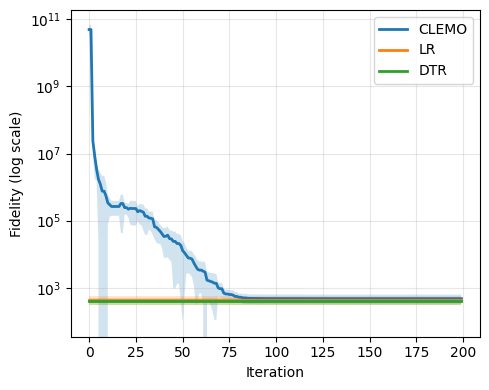

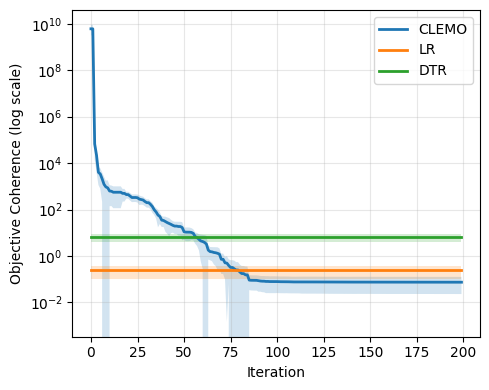

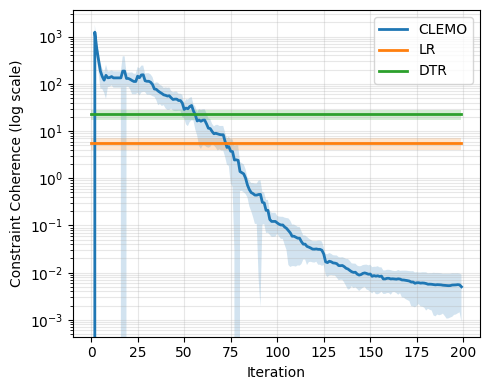

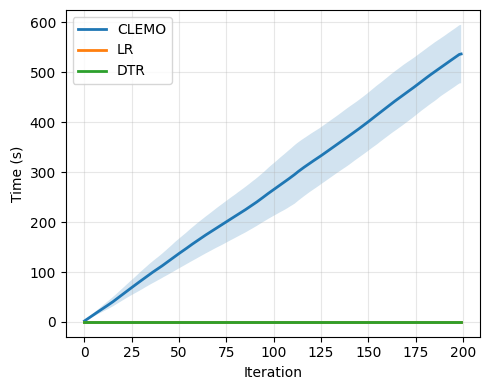

In [26]:
# Figure 2: mean +/- std over 10 instances, per metric
x = np.arange(len(itr_lst))
for key in metrics:
    fig, ax = plt.subplots(figsize=(5, 4))
    for method in ['CLEMO', 'LR', 'DTR']:
        mean = df_itr[f'{key}_{method}_mean']
        std = df_itr[f'{key}_{method}_std']
        ax.plot(x, mean, label=method, linewidth=2)
        ax.fill_between(x, mean - std, mean + std, alpha=0.2)

    ax.set_xlabel('Iteration')
    if key != 'Time (s)':
        ax.set_yscale('log')
        ax.set_ylabel(f'{key} (log scale)')
    else:
        ax.set_ylabel(key)
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()
